# Phase 3: Exploratory Data Analysis (EDA)

Now that our data is cleaned and features are engineered, we will explore the relationships between traffic volume and other variables like time, weather, and day of the week.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../dataset/processed/cleaned_traffic_data.csv')
df.head()

,temp,rain_1h,snow_1h,clouds_all,weather_main_enc,hour,day,month,weekday,is_weekend,is_rush_hour,traffic_volume
0,288.28,0.0,0.0,40,1,9,2,10,1,0,1,5545
1,289.36,0.0,0.0,75,1,10,2,10,1,0,0,4516
2,289.58,0.0,0.0,90,1,11,2,10,1,0,0,4767
3,290.13,0.0,0.0,90,1,12,2,10,1,0,0,5026
4,291.14,0.0,0.0,75,1,13,2,10,1,0,0,4918


## 2. Traffic Volume by Hour
We expect to see clear morning and evening peaks.

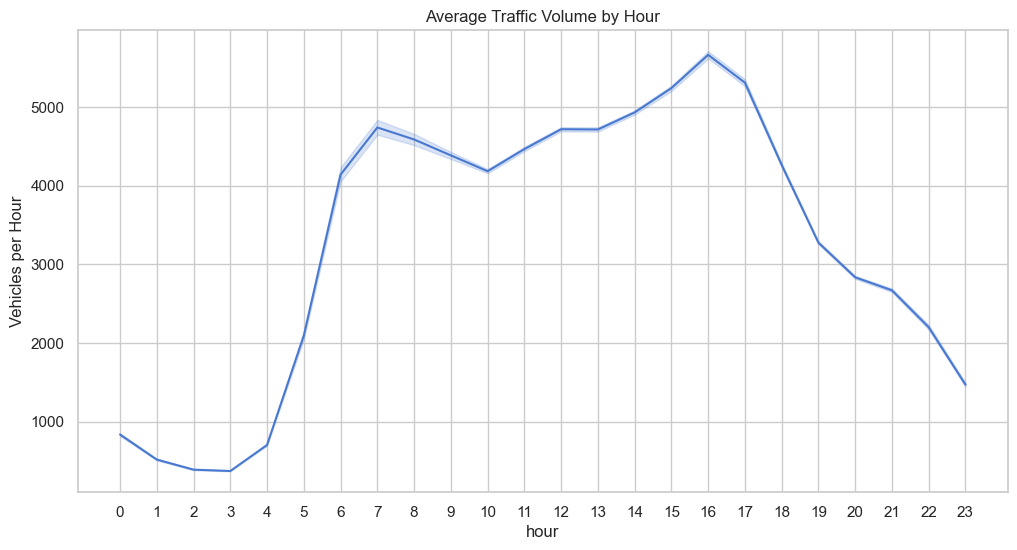

In [3]:
sns.lineplot(data=df, x='hour', y='traffic_volume')
plt.title('Average Traffic Volume by Hour')
plt.xticks(range(0, 24))
plt.ylabel('Vehicles per Hour')
plt.show()

## 3. Weekly Trends
Comparing weekdays vs weekends.

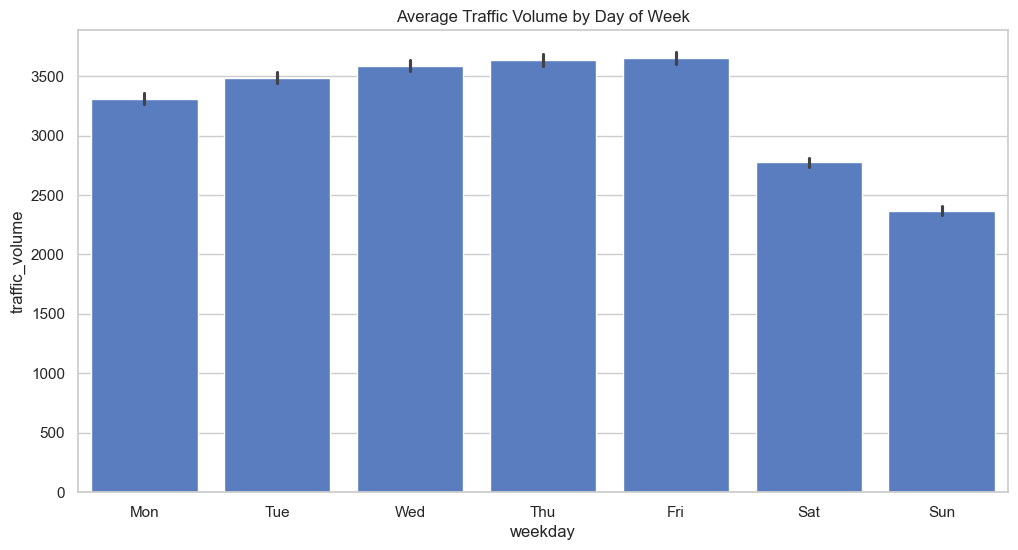

In [4]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.barplot(data=df, x='weekday', y='traffic_volume')
plt.title('Average Traffic Volume by Day of Week')
plt.xticks(range(0, 7), day_names)
plt.show()

## 4. Impact of Weather
We'll use the original weather labels from the raw data for readability if possible, but here we'll use the encoded ones or just analyze 'temp' and 'rain'.

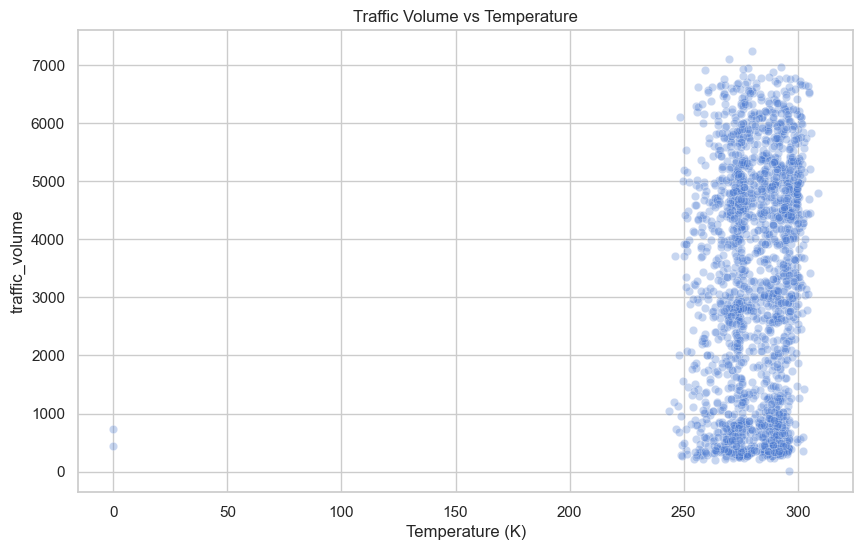

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='temp', y='traffic_volume', alpha=0.3)
plt.title('Traffic Volume vs Temperature')
plt.xlabel('Temperature (K)')
plt.show()

## 5. Correlation Heatmap
This shows us which features are most important for our model.

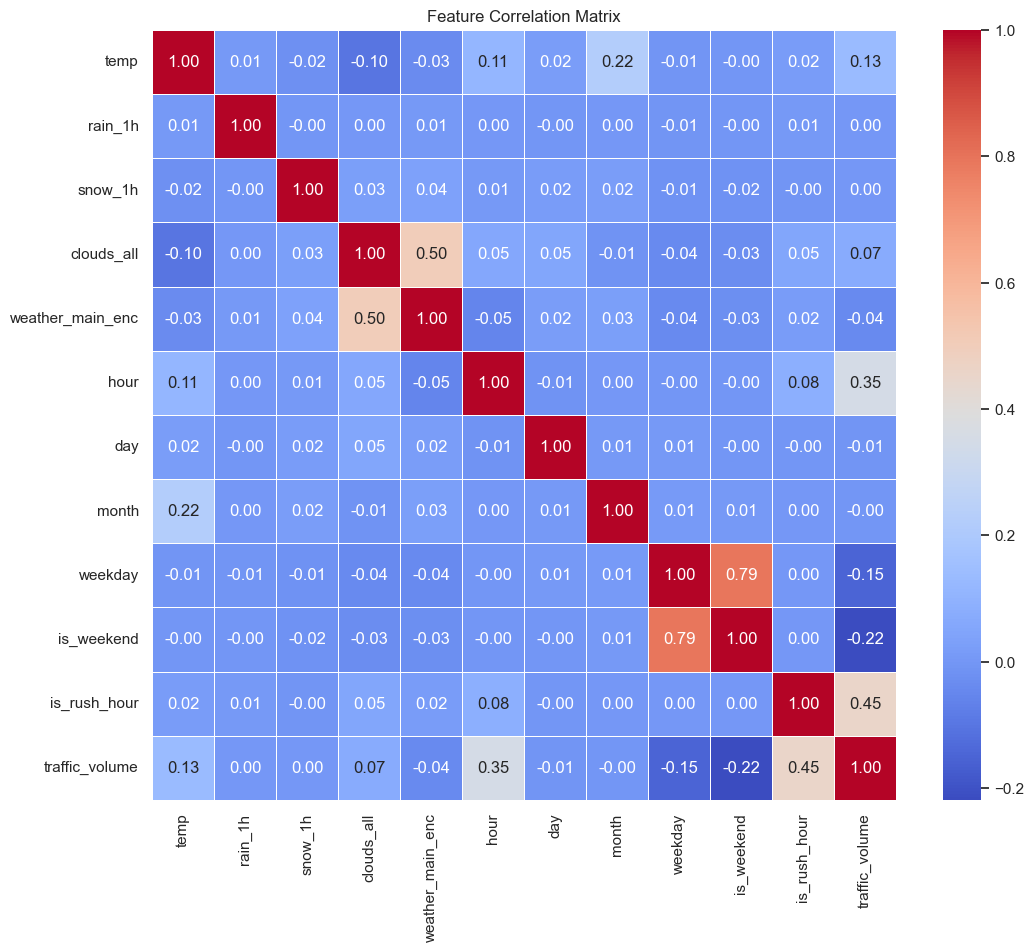

In [6]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()